# Setup

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

from src.utils import *
from src.config import np, plt, sp
import src.simulations as sim

In [3]:
a, p = sp.symbols('a p', real=True) # arrival and access probabilities symbols

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

# Throughput

In [48]:
thr = sp.factor(pi01*p + pi11*p*(1-p))
throughput_data = np.load("data/throughput_data.npy")

In [ ]:
print("\\frac {", str(thr).replace("**", "^").replace("*", "").replace("/", "}{"), "}")

\frac { -ap(p - 1)(2a^2p - a^2 - 4ap + 2a + 2p)}{(2a^3p^3 - 4a^3p^2 + 3a^3p - a^3 - 6a^2p^3 + 12a^2p^2 - 7a^2p + 2a^2 + 6ap^3 - 10ap^2 + 4ap - 2p^3 + 2p^2) }


In [141]:
throughput_data = simulate_metric(
    sim.throughput,
    time=200000,
    method="numpy",
    name ="throughput_data"
    )

Dados salvos em 'data/throughput_data.npy'.


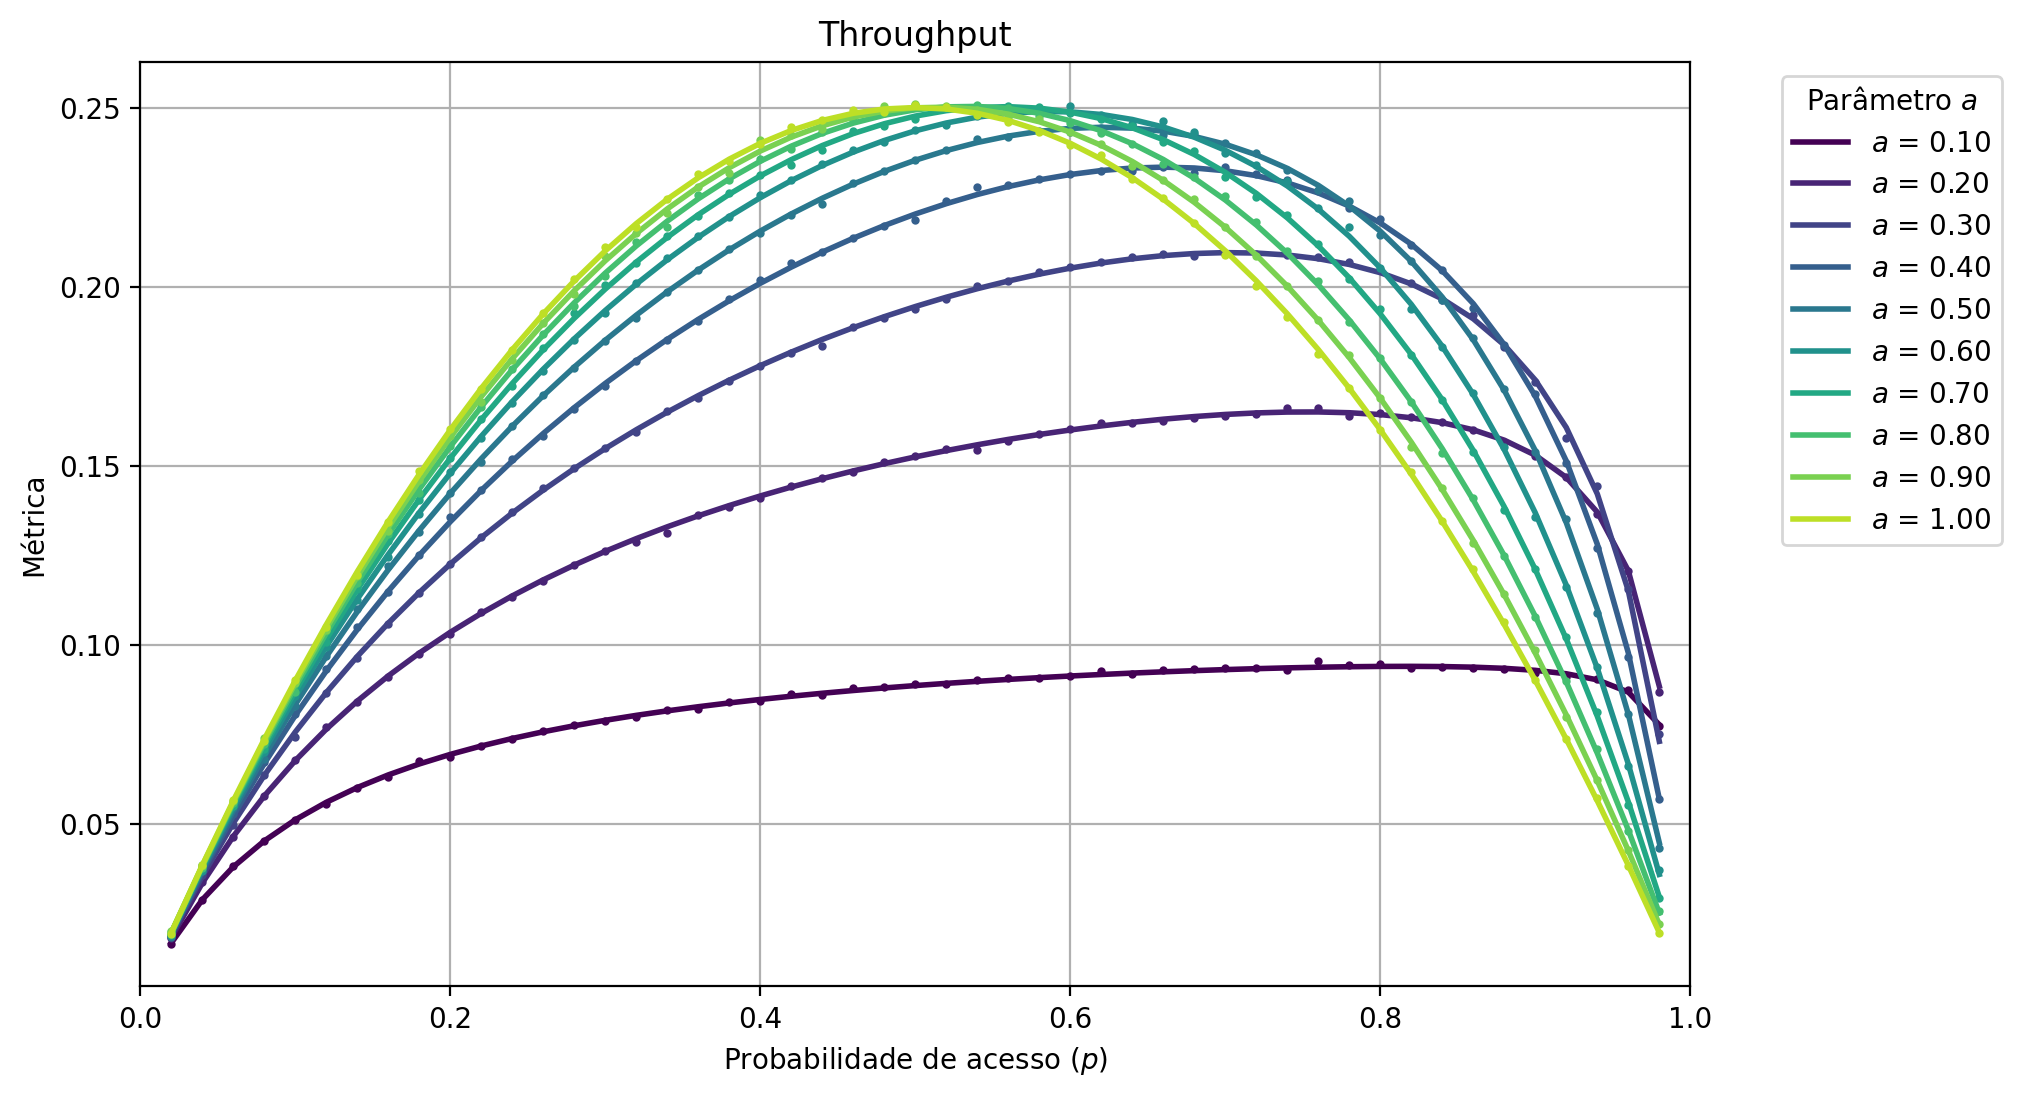

In [ ]:
compare_metric_plot(
    analytical_expr=thr,
    simulation_data=throughput_data,
    title="Throughput",
    cmap="viridis",
    axis="p"
)

# L_up

In [34]:
q0, q1 = sp.symbols('q0 q1', real=True)

# 1. Definições auxiliares do Slotted ALOHA (2 nós)
s0 = p               # Sucesso do nó 1 se nó 2 está vazio
s1 = p * (1 - p)     # Sucesso do nó 1 se nó 2 está cheio
s_neighbor = p * (1 - p)  # Sucesso do nó 2 se nó 1 está cheio (simetria)

# 2. Montando o sistema de equações
# q0 = s0 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# Se não houve chegada 'a' no nó 1, o pacote atual continua.
# Se não houve sucesso 's0', ele permanece no buffer.
eq1 = sp.Eq(q0, s0 + (1 - a) * (1 - p) * ((1 - a) * q0 + a * q1))

# q1 = s1 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# No estado 1, o vizinho pode ter sucesso (s_neighbor) e não chegar pacote novo para ele (1-a)
cont_prob_1 = (1 - a) * (1 - p * (1 - p))
trans_to_q0 = p * (1 - p) * (1 - a)
eq2 = sp.Eq(q1, p * (1 - p) + cont_prob_1 * (trans_to_q0 * q0 + (1 - trans_to_q0) * q1))

# 3. Resolvendo o sistema
solucao = sp.solve((eq1, eq2), (q0, q1))

# Simplificando os resultados
q0_expr = sp.simplify(solucao[q0])
q1_expr = sp.simplify(solucao[q1])

# AAoI e PAoI pela simulação de W_up
AAoI = W_up + 2/thr - 1     ( F )  

PAoI = W_up + 1/thr         ( V )

In [161]:
AAoI_sim_data, PAoI_sim_data = simulate_metric(sim.AAoI_PAoI_sim, time=200000, method="numpy")
np.save("data/AAoI_sim_data.npy", AAoI_sim_data)
np.save("data/PAoI_sim_data.npy", PAoI_sim_data)

KeyboardInterrupt: 

In [5]:
AAoI_sim_data = np.load("data/AAoI_sim_data.npy")
AAoI_sim_func = make_metric_func(AAoI_sim_data)
PAoI_sim_data = np.load("data/PAoI_sim_data.npy")
PAoI_sim_func = make_metric_func(PAoI_sim_data)
mean_delay_up_pack_data = np.load("data/mean_delay_up_pack_data.npy")

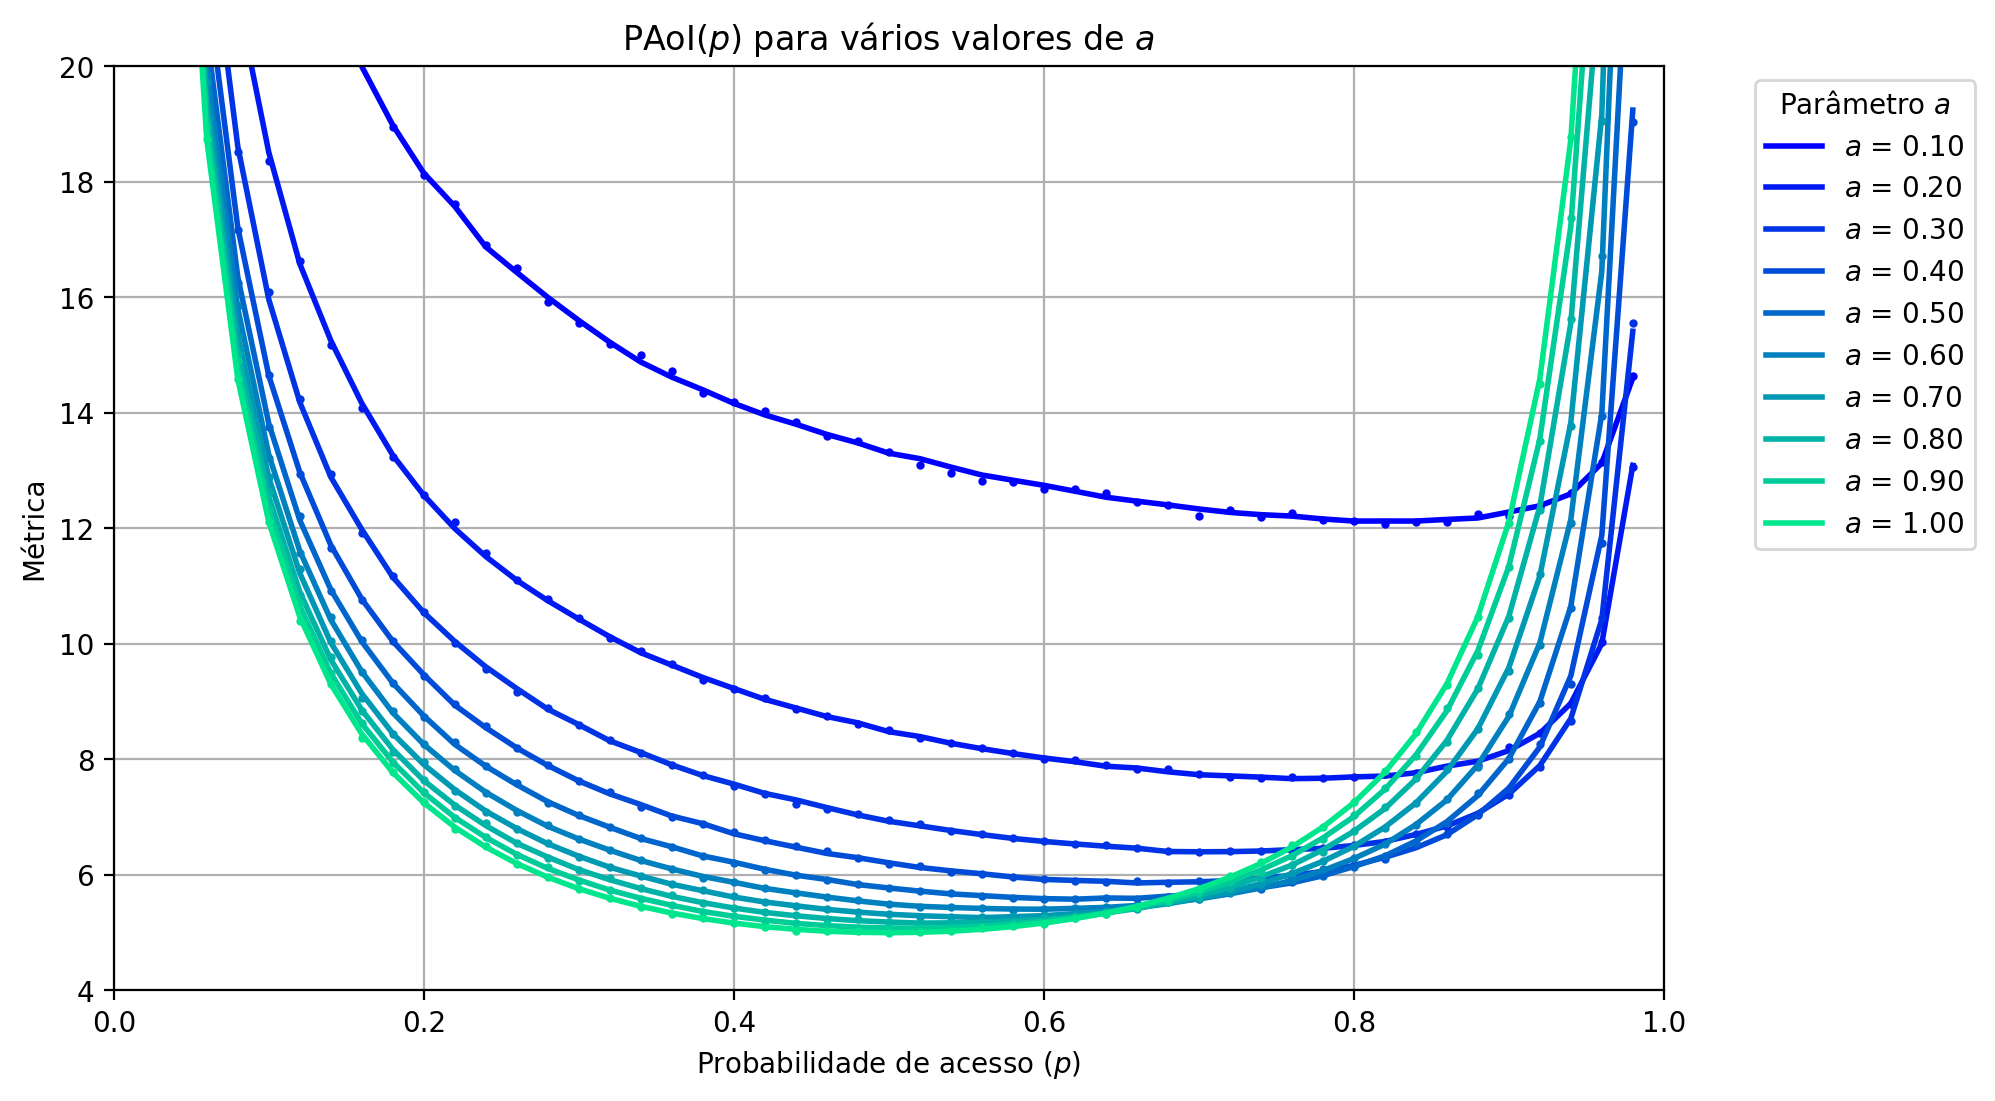

In [ ]:
thr_func = make_metric_func(thr)

W_up_sim_func = make_metric_func(mean_delay_up_pack_data)

PAoI_W_up_teste = np.vectorize(lambda a, p: W_up_sim_func(a, p) + 1 / thr_func(a, p))   
plot_metric(
    analytical_func = PAoI_W_up_teste,
    simulation_data_func = PAoI_sim_func,
    title="PAoI($p$) para vários valores de $a$",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
)

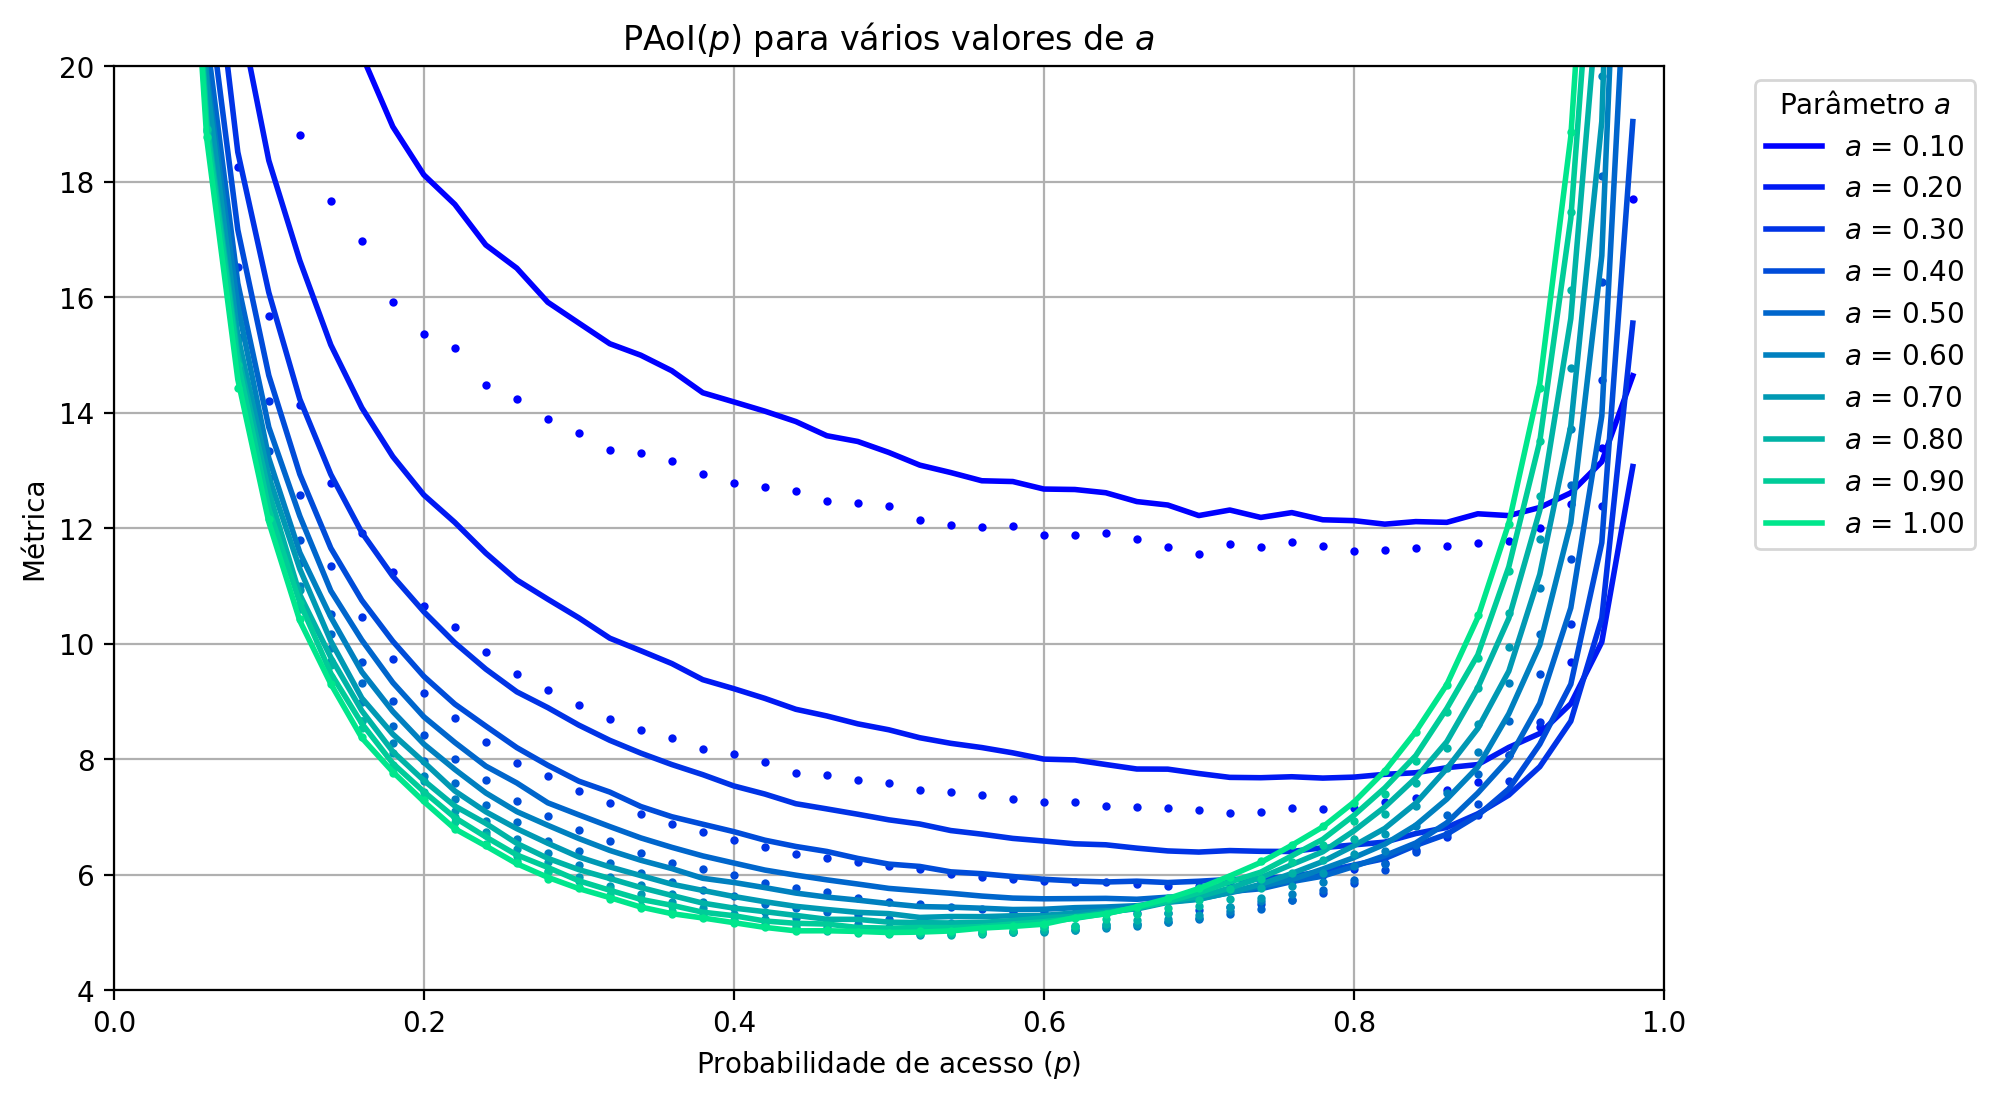

In [ ]:
AAoI_W_up_teste = np.vectorize(lambda a, p: W_up_sim_func(a, p) + 2 / thr_func(a, p) - 1)
plot_metric(
    analytical_func = PAoI_sim_func,
    simulation_data_func = AAoI_sim_func,
    title="PAoI($p$) para vários valores de $a$",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
) 

# AAoI e PAoI

## Aproximação de AAoI

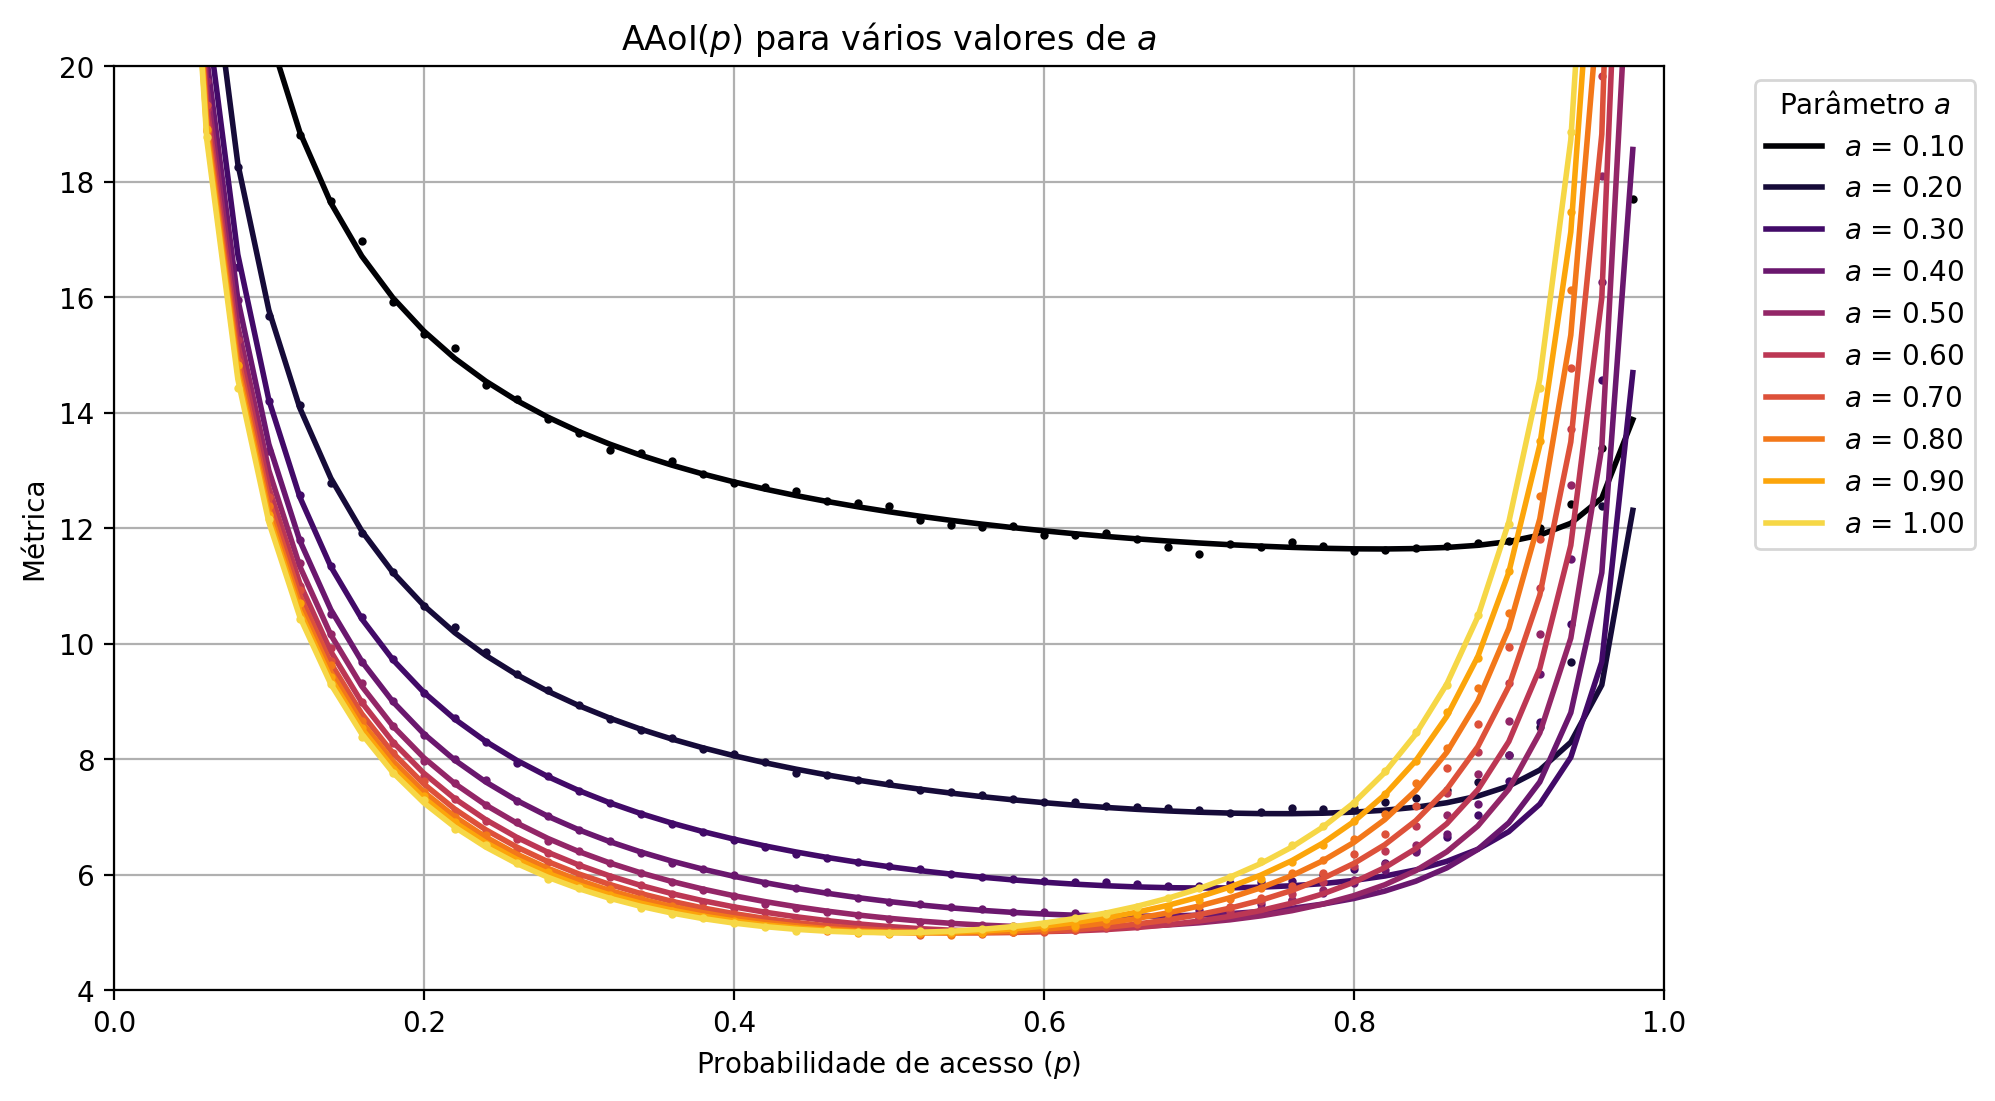

In [ ]:
AAoI_expr = sp.simplify( 1 / thr + 1 )
compare_metric_plot(
    analytical_expr=AAoI_expr,
    simulation_data=AAoI_sim_data,
    title="AAoI($p$) para vários valores de $a$",
    cmap="inferno",
    axis="p",
    yrange = (4, 20)
)

## Expressão correta para PAoI

In [10]:
L_up_expr = sp.simplify(pi10*q0_expr + pi11*q1_expr)
L_up_expr

a*p*(-a*(a*p - a - p + 2)*(a**2*p**4 - 2*a**2*p**3 + 3*a**2*p**2 - 3*a**2*p + a**2 - 2*a*p**4 + 4*a*p**3 - 6*a*p**2 + 6*a*p - 2*a + p**4 - 2*p**3 + 3*p**2 - 2*p) + p*(a**2*p - a**2 - 3*a*p + 3*a + 2*p - 2)*(a**2*p**4 - 2*a**2*p**3 + 3*a**2*p**2 - 3*a**2*p + a**2 - 2*a*p**4 + 4*a*p**3 - 6*a*p**2 + 5*a*p - 2*a + p**4 - 2*p**3 + 3*p**2 - 2*p))/((2*a**3*p**3 - 4*a**3*p**2 + 3*a**3*p - a**3 - 6*a**2*p**3 + 12*a**2*p**2 - 7*a**2*p + 2*a**2 + 6*a*p**3 - 10*a*p**2 + 4*a*p - 2*p**3 + 2*p**2)*(a**3*p**5 - 3*a**3*p**4 + 5*a**3*p**3 - 5*a**3*p**2 + 3*a**3*p - a**3 - 3*a**2*p**5 + 8*a**2*p**4 - 13*a**2*p**3 + 13*a**2*p**2 - 7*a**2*p + 2*a**2 + 3*a*p**5 - 7*a*p**4 + 11*a*p**3 - 10*a*p**2 + 4*a*p - p**5 + 2*p**4 - 3*p**3 + 2*p**2))

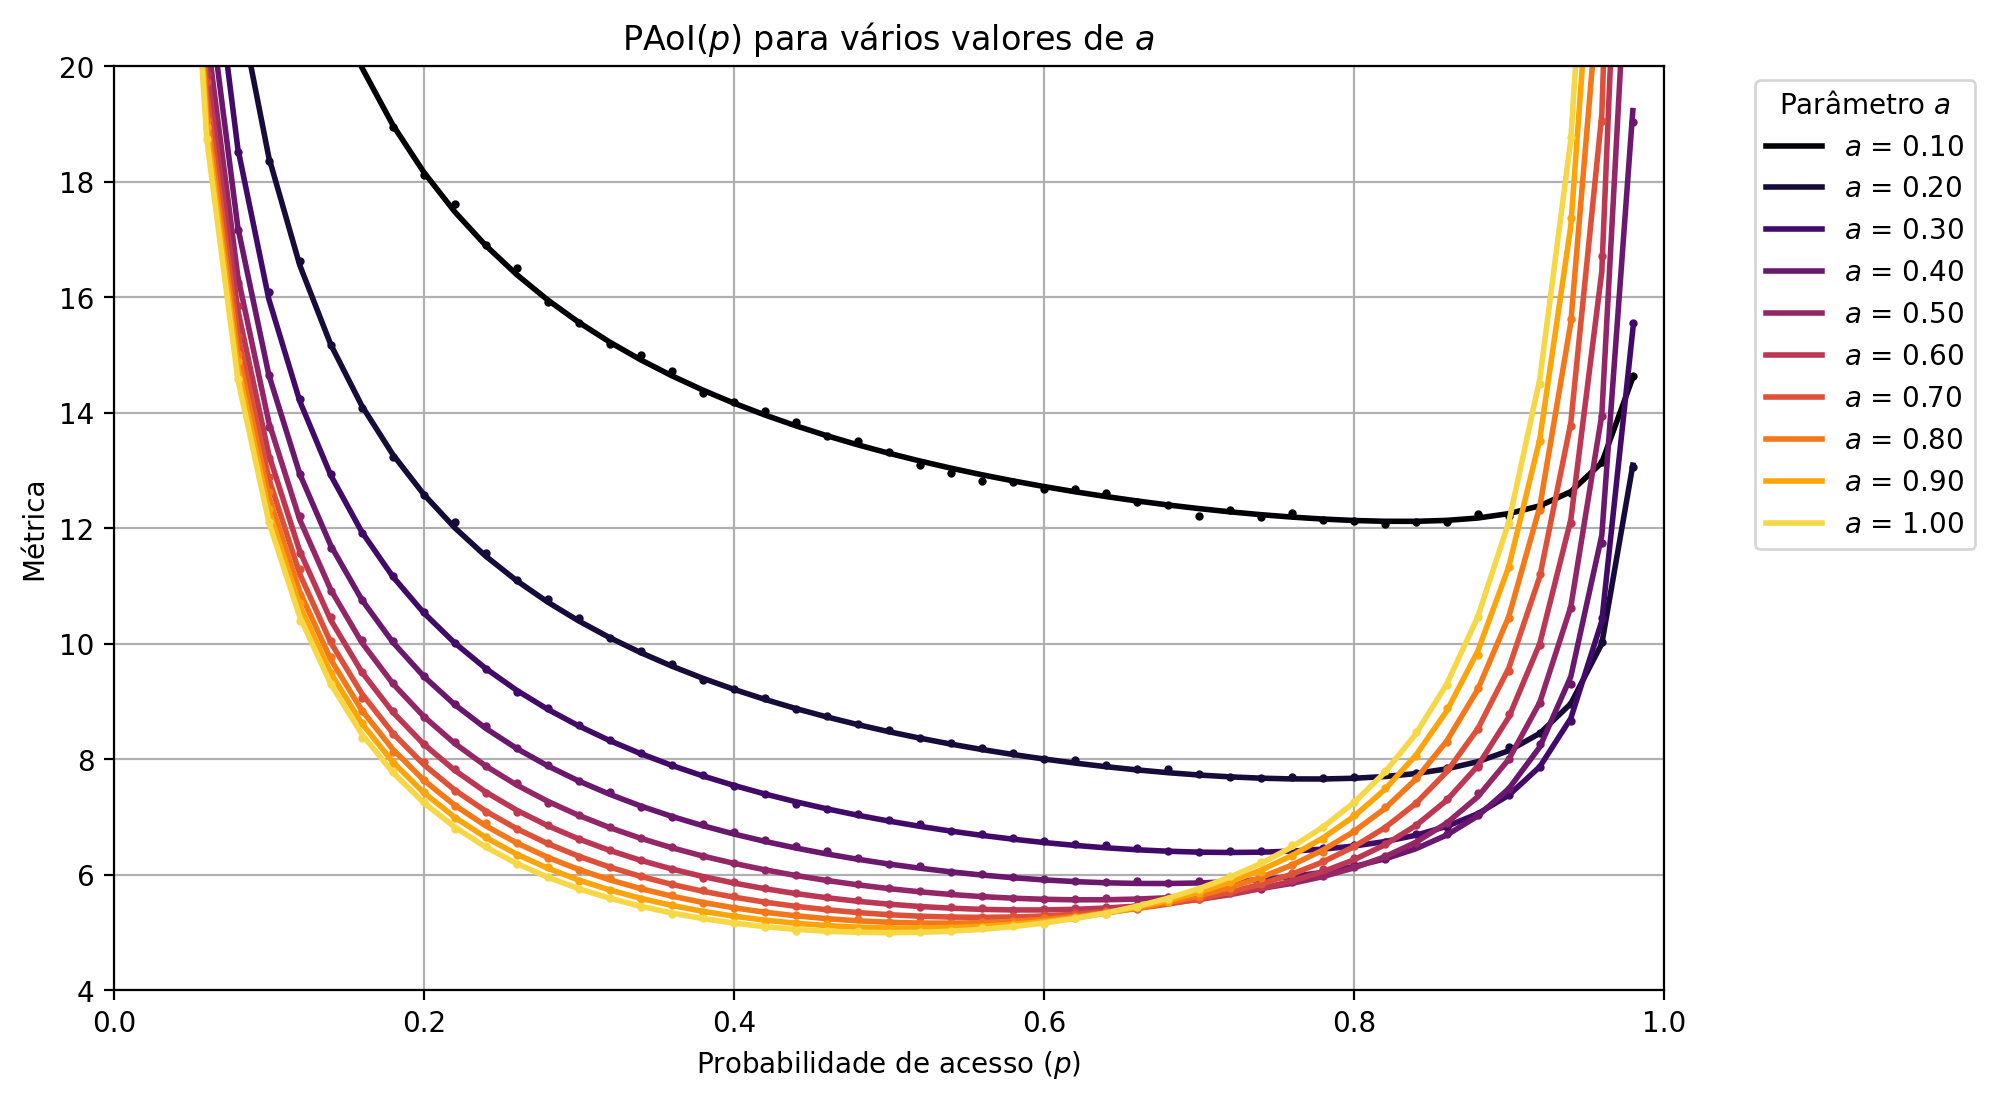

In [ ]:
# PAoI = L_up / thr + 1 / thr = (L_up + 1) / thr
# thr = thr/2
PAoI_expr = sp.simplify( (L_up_expr + 1) / thr )
# PAoI_expr = sp.simplify( (W_up) + (2 / thr))
compare_metric_plot(
    analytical_expr=PAoI_expr,
    simulation_data=PAoI_sim_data,
    title="PAoI($p$) para vários valores de $a$",
    cmap="inferno",
    axis="p",
    yrange=(4, 20)
)

# Hipótese de relação entre L_up e thr

## L_up

In [ ]:
L_tot = pi01 + pi11
taxa_desc = pi01 * a * (1 - p) + pi11 * a * (1 - p + p**2)  # validado por simulação.
L_up_expr = sp.simplify(L_tot*( thr / a ))

L_up_sim_data = np.load("data/L_up_sim_data.npy")

In [167]:
L_up_sim_data = simulate_metric(sim.occupation_up_pack, time=200000, method="numpy")
np.save("data/L_up_sim_data.npy", L_up_sim_data)

KeyboardInterrupt: 

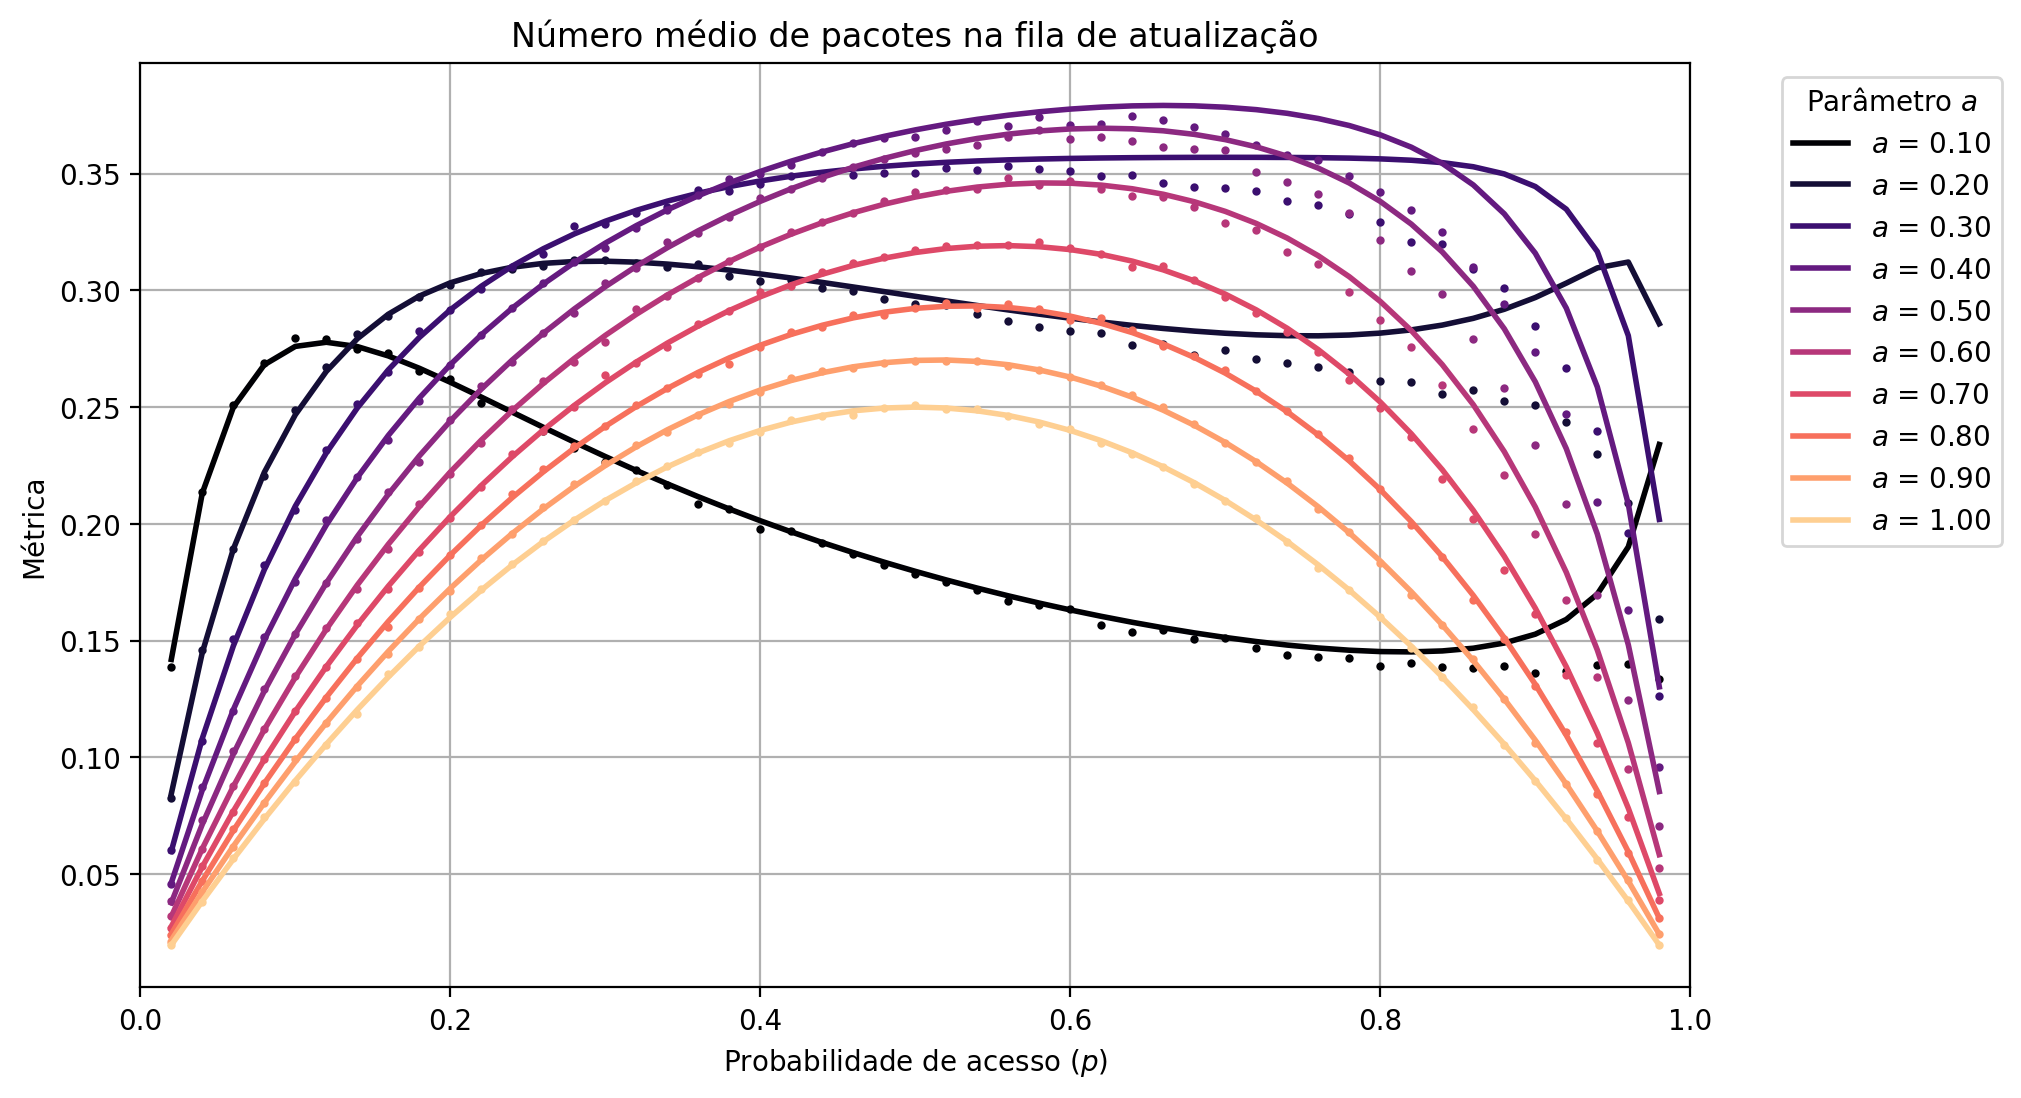

In [168]:
compare_metric_plot(
    analytical_expr=L_up_expr,
    simulation_data=L_up_sim_data,
    title="Número médio de pacotes na fila de atualização",
    cmap="magma",
    axis="p",
    # yrange=(.15, .4)
)

# True value of E[$W_{up} \cdot I$]

In [ ]:
W_up_cdot_I = np.vectorize(lambda a, p: AAoI_sim_func(a, p)/thr_func(a, p) - (2 - thr_func(a, p)) /2 /thr_func(a, p)**2)

In [18]:
sim.W_up_cdot_I(0.5,0.5,10000)

7.103032820938928

In [19]:
simulate_metric(
    metric_func = sim.W_up_cdot_I,
    time = 100000,
    name = "W_up_cdot_I",
    method="numpy"
    )
W_up_cdot_I_sim_data = np.load("data/W_up_cdot_I.npy")
W_up_cdot_I_sim_func = make_metric_func(W_up_cdot_I_sim_data)

Dados salvos em 'data/W_up_cdot_I.npy'.


In [ ]:
W_up_cdot_I_expr = sp.simplify(L_up_expr / thr**2)

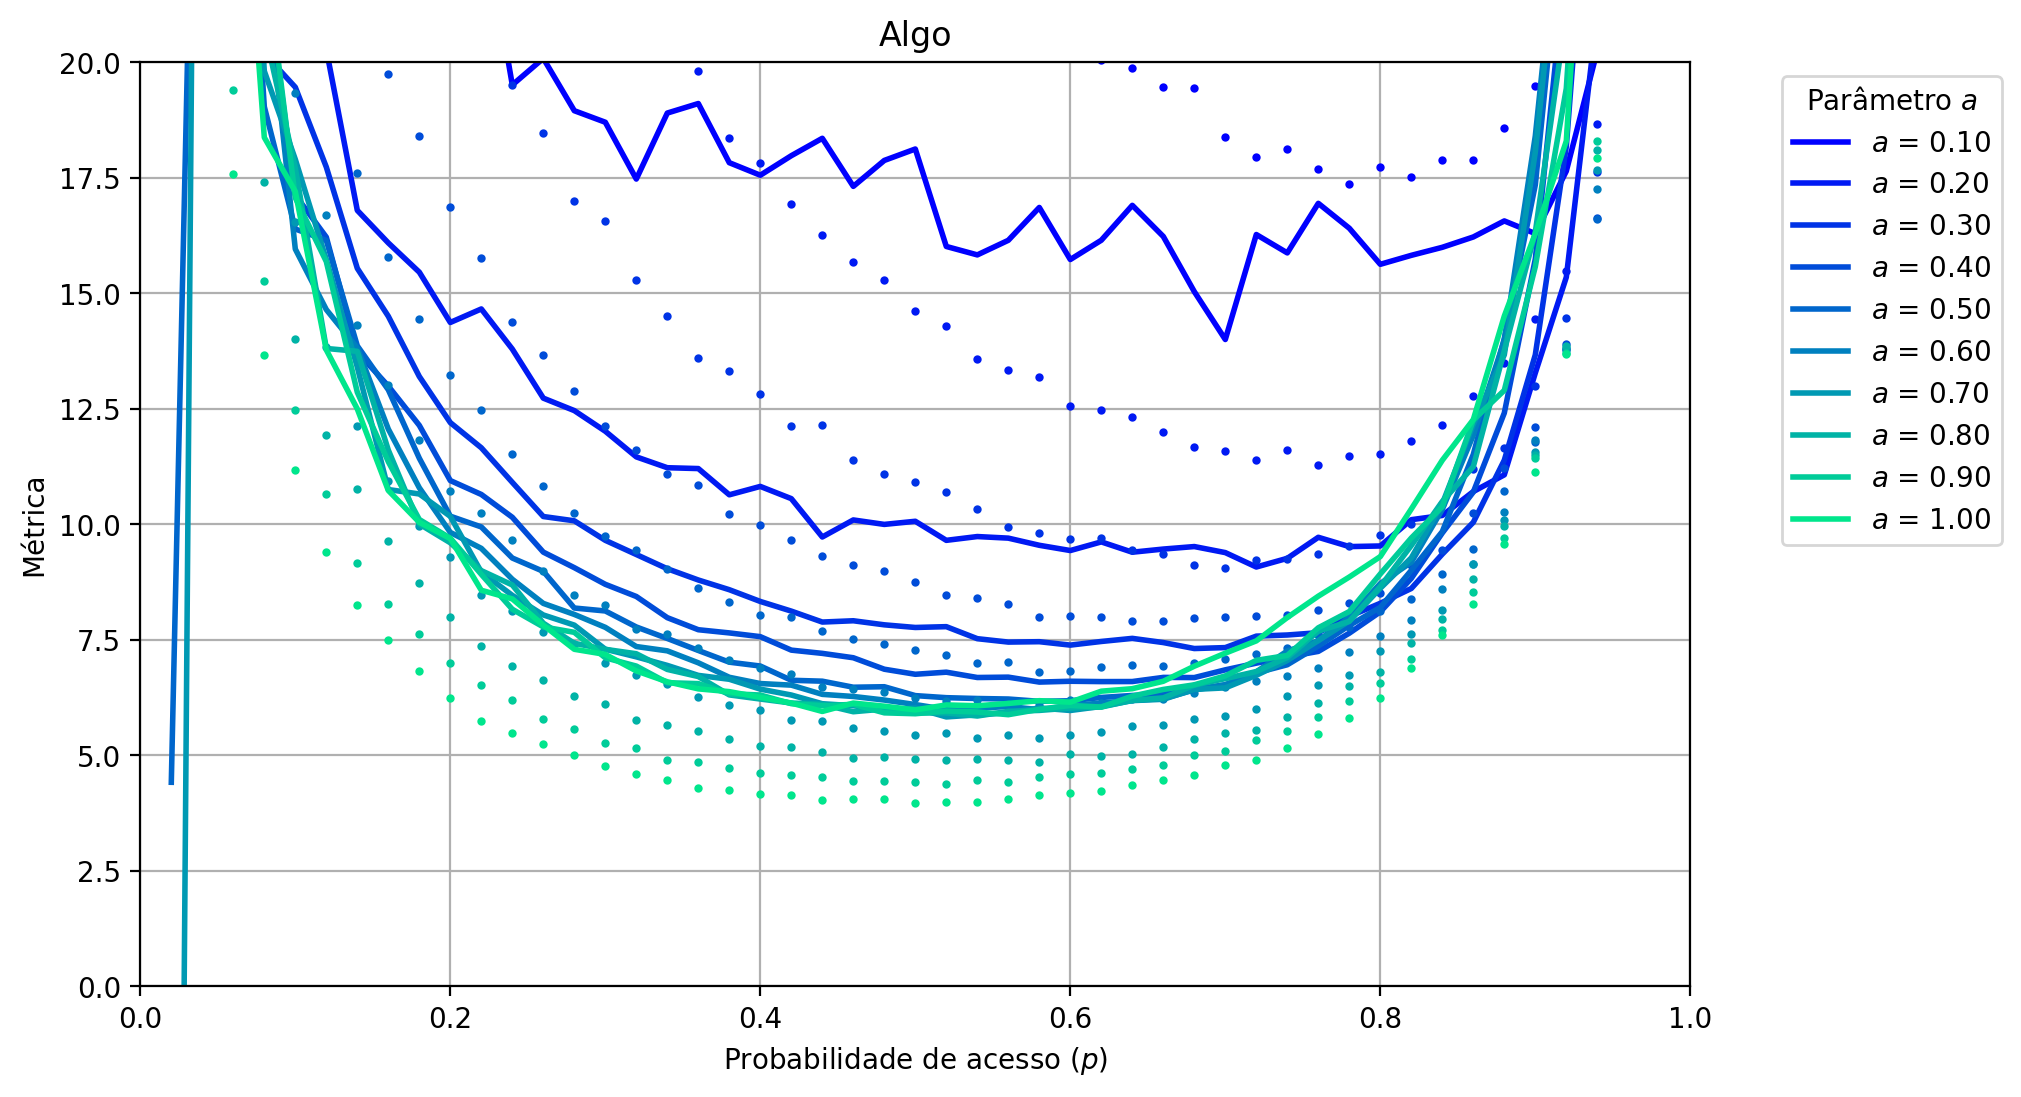

In [20]:
plot_metric(
    analytical_func = W_up_cdot_I,
    simulation_data_func = W_up_cdot_I_sim_func,
    title="Algo",
    cmap="winter",
    axis="p",
    yrange=(0, 20)
)

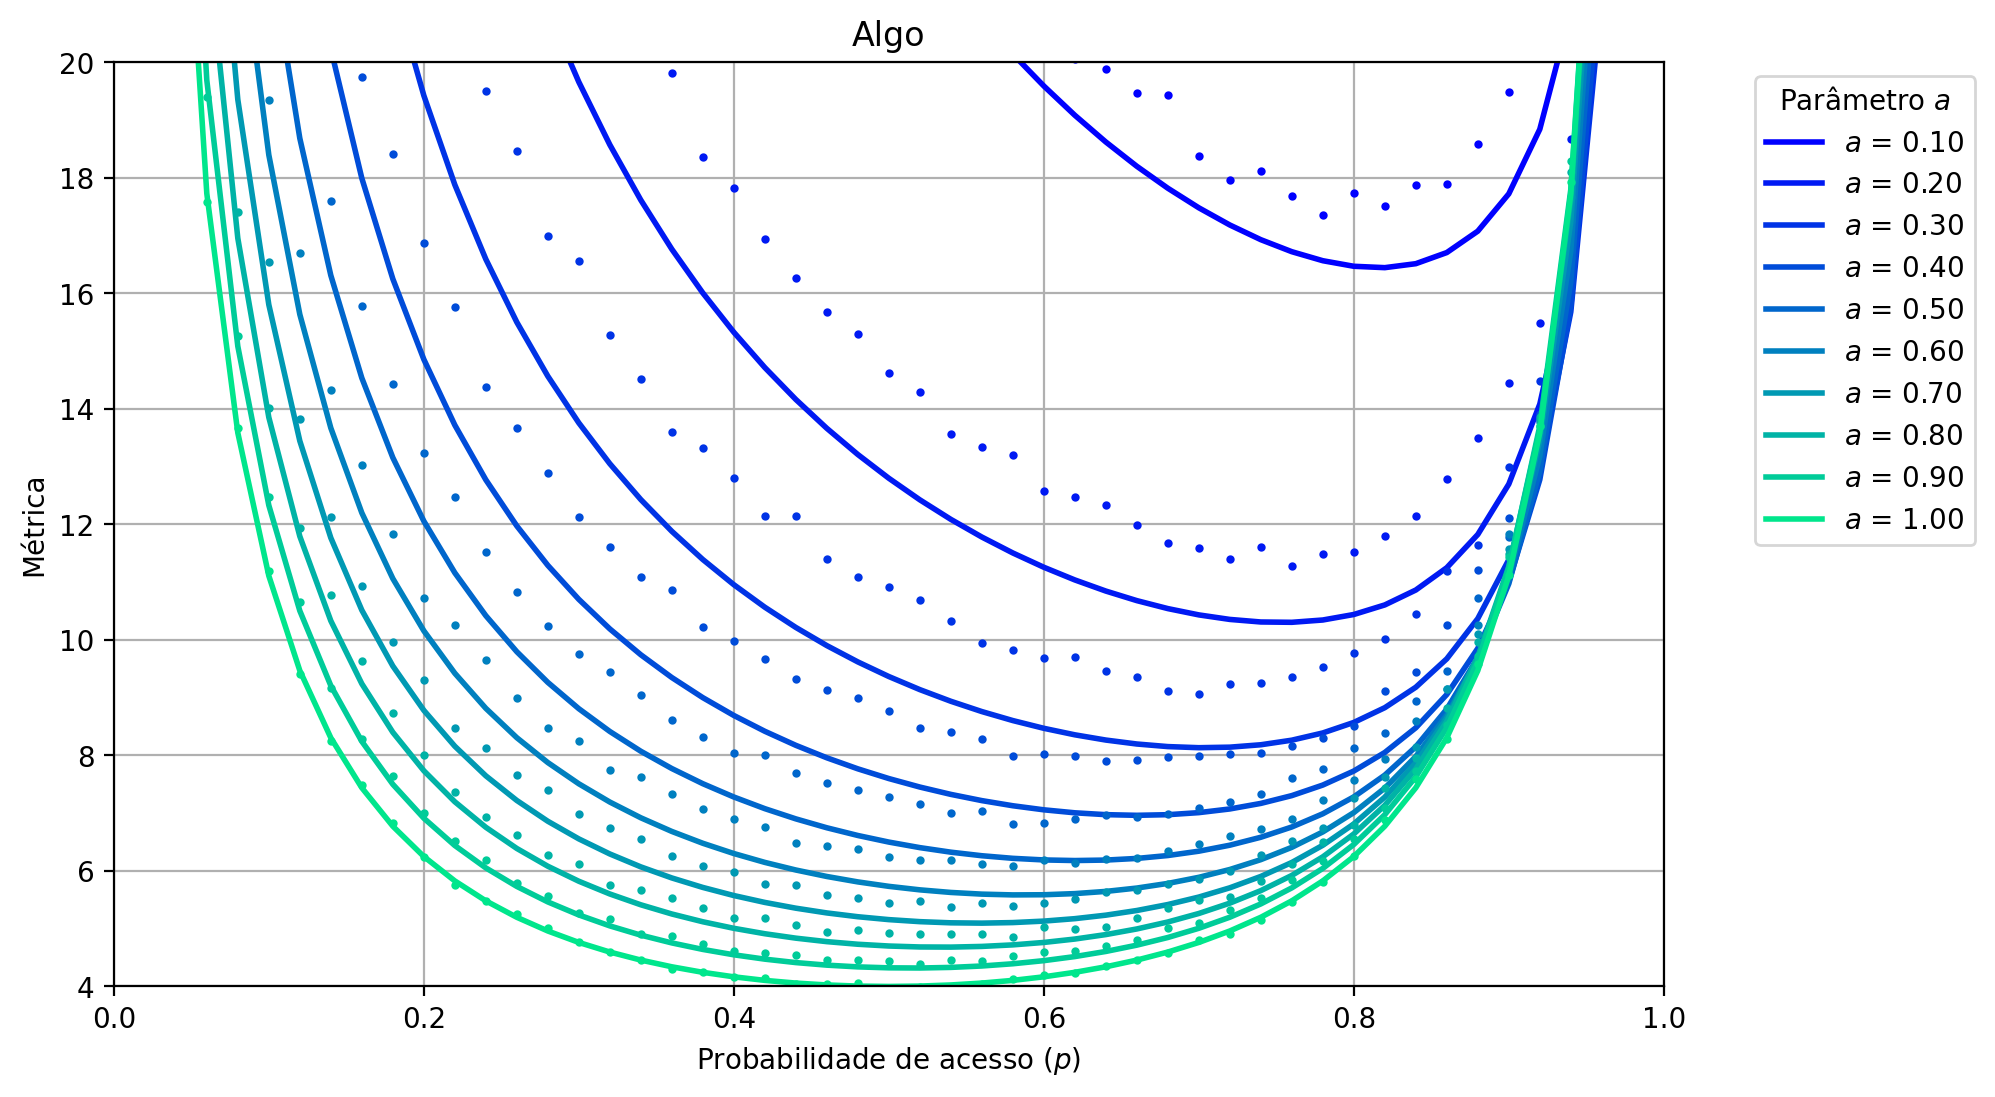

In [ ]:
compare_metric_plot(
    analytical_expr = W_up_cdot_I_expr,
    simulation_data = W_up_cdot_I_sim_data,
    title="Algo",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
)

In [41]:
I_squared_sim = simulate_metric(
    metric_func = sim.I_squared,
    time = 500000,
)

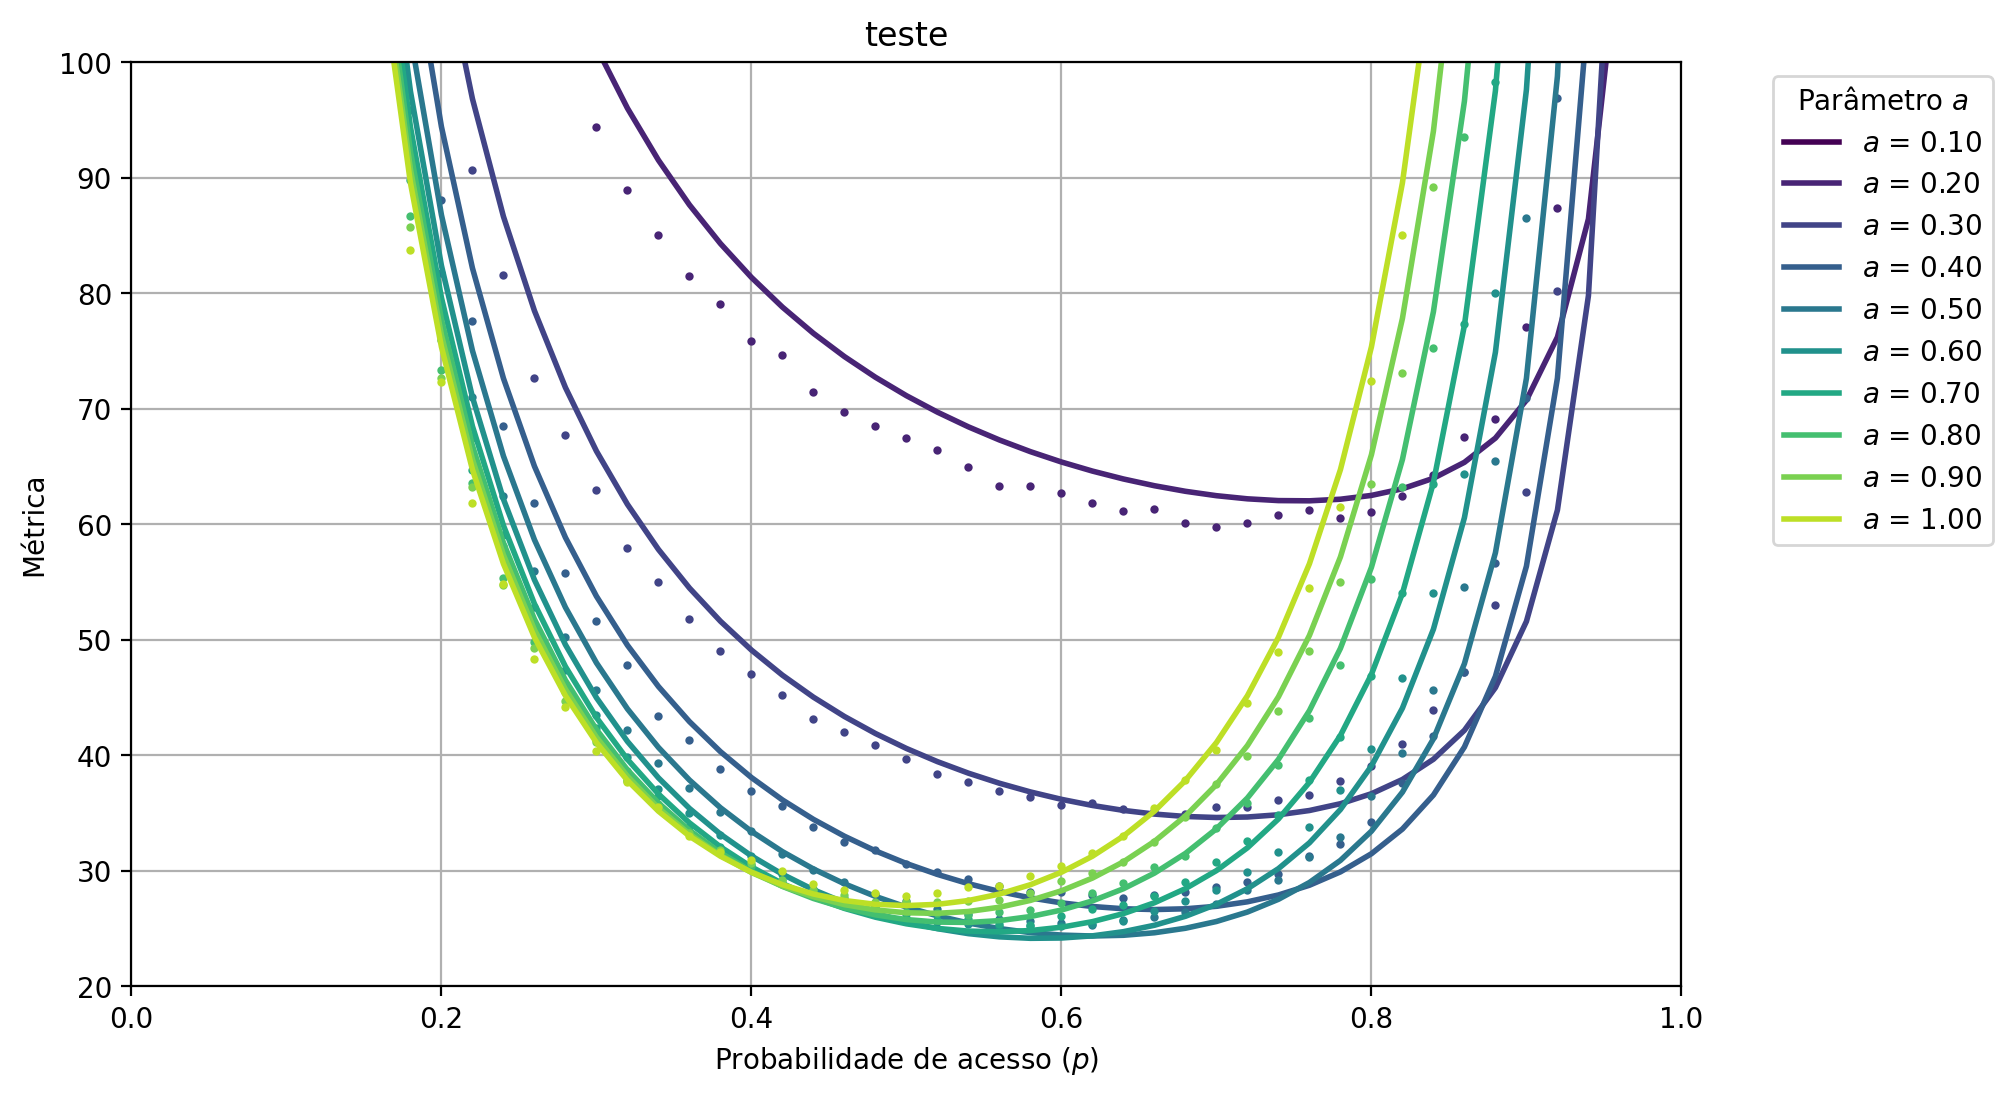

In [ ]:
p_s = thr/(pi01 + pi11)
I_squared_expr = (2-a)/a**2 + 2 /a /p_s + (2-p_s)/(p_s)**2
# I_squared_expr = (2 - thr)/thr**2
compare_metric_plot(
    analytical_expr=I_squared_expr,
    simulation_data=I_squared_sim,
    title="teste",
    cmap="viridis",
    yrange=(20,100)
)